In [122]:

%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np


###Bayesian ML functions###

from bayesian_ml import *
from packages.BayesianLinearRegression import BayesianLinearRegression
from packages.LogisticRegression import LogisticRegression
from packages.Grid2D import Grid2D
from packages.LaplaceApproximation import LaplaceApproximation
from packages.PosteriorPredictiveDistribution import PosteriorPredictiveDistribution
from packages.Hyperparameters import Hyperparameters
from packages.StationaryIsotropicKernel import StationaryIsotropicKernel
from packages.GaussianProcessRegression import GaussianProcessRegression
from packages.BayesianLinearSoftmax import BayesianLinearSoftmax
from packages.metropolis import metropolis



###Distributions###
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson
from scipy.stats import norm



snb.set_theme(font_scale=1.25)

# Part 1

## Question 1.1

We recognize that $p(y | w, \Phi, \sigma^2)$ is the likelihood which has the distribution: $$\prod_{n = 1}^{N} \mathcal{N}(f(x_{n}), \sigma^{2}) = \prod_{n = 1}^{N} \mathcal{N}(w_{0} + w_{1}x_{n} + w_{2} x_{n}^{2} + w_{3} x_{n}^{3}, \sigma^{2})$$

## Question 1.2

In [123]:
def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x, x**2, x**3))

Xtrain = jnp.array([0,1,2,4,5])
ytrain = jnp.array([1,0.5,-0.1,-0.9,1.1])
Phi = design_matrix(Xtrain)

w_MLE = (jnp.linalg.inv(Phi.T @ Phi)) @ (Phi.T @ ytrain)

Xtest = jnp.arange(0,5,0.01)

Phi_test = design_matrix(Xtest)


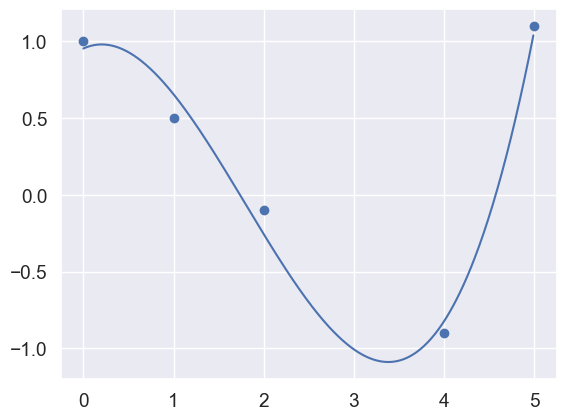

In [124]:
plt.plot(Xtest, Phi_test @ w_MLE)
plt.scatter(Xtrain, ytrain)

The weights $[w_{0},w_{1},w_{2},w_{3}]$ are

In [125]:
w_MLE

Array([ 0.95336134,  0.26645658, -0.69327731,  0.12892157], dtype=float64)

## Question 1.3

In [126]:
sigma = 1/5
beta = 1 / sigma**2

alpha = 1/2
S = alpha * jnp.eye(4) + beta * (Phi.T @ Phi)
S = jnp.linalg.inv(S)

In [127]:
A = jnp.linalg.inv(S)
m= beta*jnp.linalg.solve(A, Phi.T)@ytrain

In [128]:
S,m

(Array([[ 0.03658534, -0.04402131,  0.0148169 , -0.0014999 ],
        [-0.04402131,  0.13294307, -0.06430176,  0.00799773],
        [ 0.0148169 , -0.06430176,  0.03584205, -0.00480552],
        [-0.0014999 ,  0.00799773, -0.00480552,  0.00066975]],      dtype=float64),
 Array([ 0.9470195 ,  0.2469239 , -0.67903942,  0.12686206], dtype=float64))

## Question 1.4

In [129]:
Phi_train = design_matrix(jnp.array([3]))

mu_f = (Phi_train@m).ravel()   
var_f = jnp.diag(Phi_train@S@Phi_train.T) +  sigma**2 

In [130]:
mu_f

Array([-0.99828786], dtype=float64)

In [131]:
var_f 

Array([0.07396223], dtype=float64)

# Part 3

## Question 3.1

$$\int{[(1-z_{1}) \mathcal{N}(y_{1} | 0,1) + z_{1} \mathcal{N}(y_{1} | \theta^{T} x_{1},\sigma^{2})] \cdot \text{Ber}(z_{1} | \pi) \mathcal{N}(\theta | 0, \alpha^{-1} I)} \, dz_{1}$$

$$= [(1-\pi) \mathcal{N}(y_{1} | 0,1) + \pi \mathcal{N}(y_{1} | \theta^{T} x_{1},\sigma^{2})] \mathcal{N}(\theta | 0, \alpha^{-1} I)$$

## Question 3.3

In [132]:
d = 2
v = jnp.array([6/5, 6/5]) 
mu = jnp.array([1/4,1/4])

sigma = jnp.diag(v)

d/2 + d/2*jnp.log(2 * jnp.pi) + 1/2*jnp.log(jnp.linalg.det(sigma))

Array(3.02019862, dtype=float64)

## Question 3.4

In [133]:
norm.interval(0.95, loc = 1/4, scale = jnp.sqrt(6/5))

(np.float64(-1.8970329724605883), np.float64(2.3970329724605883))

## Question 3.5

In [134]:
x_star = jnp.array([-1,3])
mu = jnp.array([1/4,1/4])

x_star @ mu

Array(0.5, dtype=float64)

In [135]:
x_star @ jnp.diag(v) @ x_star + 1/10

Array(12.1, dtype=float64)

# Part 4

## Question 4.1

In [136]:
k1 = lambda x,xi: 5 * (1 + jnp.exp(-1/4 * (x - xi)**2))
k1(4,4)

Array(10., dtype=float64, weak_type=True)

## Question 4.3

In [137]:
m = jnp.array([1.56,0.84,-0.32])
S = jnp.array([[2.69, 1.46, 0.42],[1.46, 1.78, 1.2],[0.42, 1.2, 2.13]])

X = jnp.array([1,2,3])
Xstar = jnp.array([4])
y = jnp.array([1,1,0])


# Broadcast: x as column, xi as row -> (100, 50) matrix
k = k1(Xstar[:,None], X[None,:])
K = k1(X[:,None],X[None,:])
Kp = k1(Xstar[:,None], Xstar[None,:])



In [138]:
h = jnp.linalg.solve(K, k.T)
mu = k@jnp.linalg.solve(K, m)
Sigma = Kp - h.T@(K-S)@h

In [139]:
mu,Sigma

(Array([-0.70821841], dtype=float64), Array([[4.16431588]], dtype=float64))

# Question 4.4

In [140]:
probit = lambda x: norm.cdf(x)

probit(mu/jnp.sqrt(8/jnp.pi + jnp.diag(Sigma)))

array([0.3922773])